# Ejercicio de programación Regresión Lineal Múltiple
## Laboratorio 02 — Dataset: Retrasos de Vuelos (Flight Delays 2015)

Este cuadernillo mantiene el **mismo algoritmo de regresión lineal múltiple** revisado en clases
(`featureNormalize`, `computeCostMulti`, `gradientDescentMulti`, `normalEqn`), pero reemplaza el
dataset de ejemplo (`ex1data2.txt`, precios de casas) por un dataset propio de mayor tamaño:

- **Dataset:** [2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays) (Kaggle)
- **Variable objetivo (y):** `ARRIVAL_DELAY` (retraso de llegada en minutos)
- **m (muestras):** 700,000 filas (>= 20,000 requerido)
- **n (características):** 7 variables numéricas + variables dummy de aerolínea (>= 20 requerido)

El preprocesamiento del dataset (lectura, filtrado, limpieza y codificación one-hot) se hace con
**Pandas**, tal como pide el enunciado.

In [ ]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Manejo y preprocesamiento del dataset
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

### 0.1 Montar Dataset (Local o de drive)

Si trabajas en **Google Colab** y el archivo `flights.csv` está guardado en tu Drive, monta la
unidad y ajusta la variable `ARCHIVO_CSV` con la ruta correspondiente. Si vas a ejecutar el
cuadernillo localmente (Jupyter) con `flights.csv` en la misma carpeta, puedes omitir esta celda.

In [ ]:
# Descomentar si se ejecuta en Google Colab y el CSV está en Drive
# from google.colab import drive
# drive.mount("/content/gdrive")
# ARCHIVO_CSV = "/content/gdrive/MyDrive/Colab Notebooks/machine learning/datasets/flights.csv"

# Ruta local (dataset en la misma carpeta que el notebook)
ARCHIVO_CSV = 'Dataset/flights.csv'

## 1. Lectura y preprocesamiento del dataset (Pandas)

Se define una función que replica el flujo de `leerDataset.py`:

1. Lee únicamente las columnas necesarias del CSV (para no saturar la RAM).
2. Filtra vuelos cancelados y desviados (`CANCELLED == 0` y `DIVERTED == 0`).
3. Elimina filas con valores nulos en las columnas clave.
4. Aplica codificación **One-Hot** a la aerolínea (`AIRLINE`) con `drop_first=True` para evitar
   multicolinealidad.
5. Construye la matriz de características `X` (variables numéricas + dummies de aerolínea) y el
   vector objetivo `y` (`ARRIVAL_DELAY`), **sin normalizar todavía** — la normalización se hace
   más adelante con la función `featureNormalize` (la misma usada en clases), para mantener el
   mismo algoritmo del cuadernillo original.

In [ ]:
MIN_FILAS = 700000 

def preprocesar_datos_vuelos(ruta_archivo, n_filas_objetivo):
    print("1. Leyendo columnas necesarias del archivo CSV...")

    columnas_utiles = [
        'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE',
        'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL',
        'DISTANCE', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
        'CANCELLED', 'DIVERTED'
    ]

    df = pd.read_csv(ruta_archivo, usecols=columnas_utiles)
    print(f"   - Filas originales leídas: {len(df):,}")

    print("2. Filtrando vuelos cancelados y desviados...")
    df = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()
    df = df.drop(columns=['CANCELLED', 'DIVERTED'])

    print("3. Eliminando valores nulos...")
    columnas_clave = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'DISTANCE', 'SCHEDULED_DEPARTURE']
    df = df.dropna(subset=columnas_clave)

    if len(df) < n_filas_objetivo:
        raise ValueError(
            f"El dataset filtrado tiene {len(df)} filas, menor al mínimo requerido "
            f"({n_filas_objetivo})."
        )

    df = df.head(n_filas_objetivo)
    print(f"   - Filas listas para el entrenamiento: {len(df):,}")

    print("4. Aplicando One-Hot Encoding a la aerolínea (drop_first=True)...")
    df_aerolineas = pd.get_dummies(df['AIRLINE'], prefix='AIRLINE', drop_first=True, dtype=int)

    print("5. Construyendo las matrices X e y (sin normalizar aún)...")
    columnas_numericas = [
        'DISTANCE', 'DEPARTURE_DELAY', 'SCHEDULED_DEPARTURE',
        'SCHEDULED_ARRIVAL', 'MONTH', 'DAY_OF_WEEK', 'DAY'
    ]

    X_num = df[columnas_numericas].reset_index(drop=True)
    X_df = pd.concat([X_num, df_aerolineas.reset_index(drop=True)], axis=1)
    y_series = df['ARRIVAL_DELAY'].reset_index(drop=True)

    print("\n¡Preprocesamiento completado exitosamente!")
    print(f"Dimensiones de X (sin bias): {X_df.shape}   ->   n = {X_df.shape[1]} características")
    print(f"Dimensiones de y: {y_series.shape}   ->   m = {y_series.shape[0]} muestras")

    return X_df, y_series

X_df, y_series = preprocesar_datos_vuelos(ARCHIVO_CSV, MIN_FILAS)
X_df.head()

1. Leyendo columnas necesarias del archivo CSV...
   - Filas originales leídas: 5,819,079
2. Filtrando vuelos cancelados y desviados...
3. Eliminando valores nulos...
   - Filas listas para el entrenamiento: 700,000
4. Aplicando One-Hot Encoding a la aerolínea (drop_first=True)...
5. Construyendo las matrices X e y (sin normalizar aún)...

¡Preprocesamiento completado exitosamente!
Dimensiones de X (sin bias): (700000, 20)   ->   n = 20 características
Dimensiones de y: (700000,)   ->   m = 700000 muestras


,DISTANCE,DEPARTURE_DELAY,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,MONTH,DAY_OF_WEEK,DAY,AIRLINE_AS,AIRLINE_B6,AIRLINE_DL,AIRLINE_EV,AIRLINE_F9,AIRLINE_HA,AIRLINE_MQ,AIRLINE_NK,AIRLINE_OO,AIRLINE_UA,AIRLINE_US,AIRLINE_VX,AIRLINE_WN
0,1448,-11.0,5,430,1,4,1,1,0,0,0,0,0,0,0,0,0,0,0,0
1,2330,-8.0,10,750,1,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2296,-2.0,20,806,1,4,1,0,0,0,0,0,0,0,0,0,0,1,0,0
3,2342,-5.0,20,805,1,4,1,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1448,-1.0,25,320,1,4,1,1,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
# Conversión a matrices NumPy (formato requerido por las funciones del algoritmo)
nombres_columnas = list(X_df.columns)
X = X_df.to_numpy(dtype=float)
y = y_series.to_numpy(dtype=float)
m = y.size

print(f"m (muestras)        = {m:,}")
print(f"n (características) = {X.shape[1]}")
print("Columnas de X:", nombres_columnas)

m (muestras)        = 700,000
n (características) = 20
Columnas de X: ['DISTANCE', 'DEPARTURE_DELAY', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL', 'MONTH', 'DAY_OF_WEEK', 'DAY', 'AIRLINE_AS', 'AIRLINE_B6', 'AIRLINE_DL', 'AIRLINE_EV', 'AIRLINE_F9', 'AIRLINE_HA', 'AIRLINE_MQ', 'AIRLINE_NK', 'AIRLINE_OO', 'AIRLINE_UA', 'AIRLINE_US', 'AIRLINE_VX', 'AIRLINE_WN']


<a id="section4"></a>
### 1.1 Normalización de características

Al igual que en el ejemplo de precios de casas, las características tienen magnitudes muy
distintas (p. ej. `DISTANCE` en millas vs `DAY_OF_WEEK` entre 1 y 7), por lo que se normalizan
para que el descenso por el gradiente converja más rápido. Se reutiliza la misma función
`featureNormalize` vista en clases.

In [5]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

### 1.2 División en entrenamiento y prueba

Para poder evaluar el modelo con datos que no vio durante el entrenamiento (y así saber si el
error de costo obtenido es confiable), se separa el dataset en 80% entrenamiento / 20% prueba
**antes** de calcular `mu` y `sigma`, evitando fuga de información (*data leakage*).

In [6]:
np.random.seed(42)
indices = np.random.permutation(m)

frac_train = 0.8
n_train = int(m * frac_train)

idx_train, idx_test = indices[:n_train], indices[n_train:]

X_train_raw, y_train = X[idx_train], y[idx_train]
X_test_raw, y_test = X[idx_test], y[idx_test]

print(f"Muestras de entrenamiento: {X_train_raw.shape[0]:,}")
print(f"Muestras de prueba:        {X_test_raw.shape[0]:,}")

# Normalizamos usando SOLO estadísticas del set de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train_raw)
X_test_norm = (X_test_raw - mu) / sigma  # mismas mu/sigma del entrenamiento

# Se añade la columna de sesgo (bias / intercepto theta_0)
X_train = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print("Forma final de X_train (con bias):", X_train.shape)
print("Forma final de X_test  (con bias):", X_test.shape)

Muestras de entrenamiento: 560,000
Muestras de prueba:        140,000
Forma final de X_train (con bias): (560000, 21)
Forma final de X_test  (con bias): (140000, 21)


<a id="section5"></a>
## 2. Descenso por el gradiente

Las funciones `computeCostMulti` y `gradientDescentMulti` son idénticas a las vistas en clases:
están vectorizadas y soportan cualquier número de características `n`, por lo que no requieren
cambios para trabajar con las 20+ columnas del dataset de vuelos.

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

In [21]:
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [22]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

### 2.1 Selección del coeficiente de aprendizaje (alpha)

Se prueban varios valores de `alpha` con pocas iteraciones para comparar su velocidad de
convergencia **graficando el costo J en función del número de iteraciones** para cada uno. Esto
permite elegir el `alpha` más grande que aún converge de forma estable, y así entrenar el modelo
final con el menor error de costo posible.

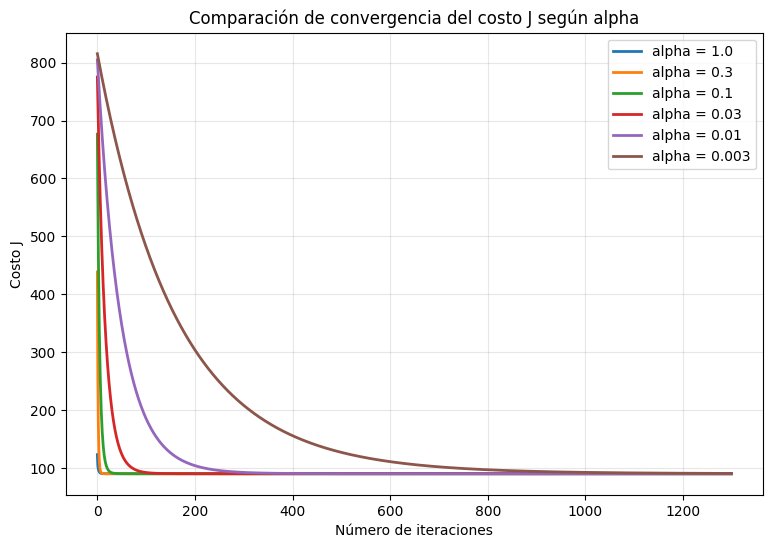

In [25]:
alphas_a_probar = [1.0, 0.3, 0.1, 0.03, 0.01, 0.003]
iters_prueba = 1300

pyplot.figure(figsize=(9, 6))

for a in alphas_a_probar:
    theta_ini = np.zeros(X_train.shape[1])
    _, J_hist = gradientDescentMulti(X_train, y_train, theta_ini, a, iters_prueba)
    pyplot.plot(np.arange(len(J_hist)), J_hist, lw=2, label=f'alpha = {a}')

pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Comparación de convergencia del costo J según alpha')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.show()

### 2.2 Entrenamiento final

Con el `alpha` elegido (ajusta el valor según lo observado en la gráfica anterior) se entrena el
modelo con un número mayor de iteraciones y se grafica la **curva final de la función de costo J
respecto al número de iteraciones**.

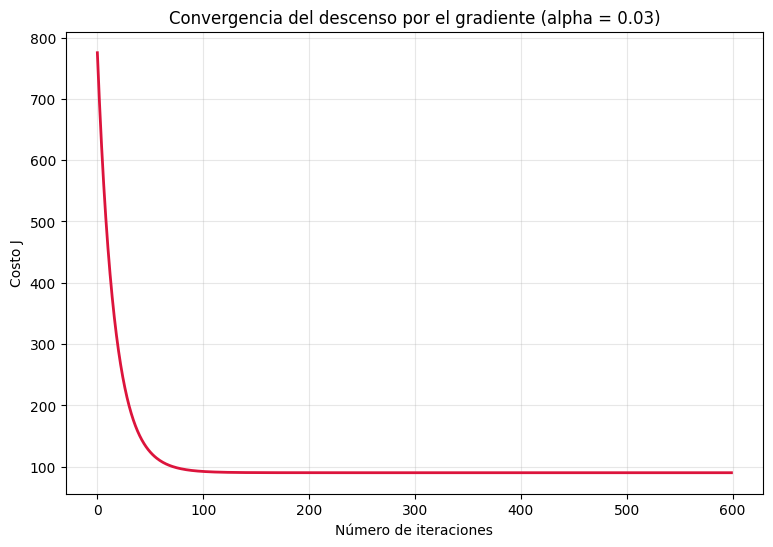

Costo final de entrenamiento (J): 90.1929
theta calculado por el descenso por el gradiente:
[ 5.91501779 -1.60702171 37.47437971 -0.53295255  0.26704453 -0.40933894
 -0.41986502 -0.95789821  0.15513184  0.39441128 -1.48174485  0.33126126
  0.48450261  0.67764778  0.99498808  0.31488102  0.29728386 -0.88644461
  0.3365426  -0.04785756 -1.31564266]


In [26]:
# Elegir el alpha con mejor convergencia observado en la comparación anterior
alpha = 0.03
num_iters = 600

theta = np.zeros(X_train.shape[1])
theta, J_history = gradientDescentMulti(X_train, y_train, theta, alpha, num_iters)

# Gráfica de la función de costo J vs número de iteraciones
pyplot.figure(figsize=(9, 6))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='crimson')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title(f'Convergencia del descenso por el gradiente (alpha = {alpha})')
pyplot.grid(True, alpha=0.3)
pyplot.show()

print(f"Costo final de entrenamiento (J): {J_history[-1]:.4f}")
print(f"theta calculado por el descenso por el gradiente:\n{theta}")

### 2.3 Evaluación sobre el set de prueba

Se calcula el costo `J` y el coeficiente de determinación $R^2$ sobre los datos de **prueba**
(no usados en el entrenamiento) para verificar que el modelo generaliza correctamente.

In [27]:
def r2_score(y_true, y_pred):
    ss_res = np.sum(np.square(y_true - y_pred))
    ss_tot = np.sum(np.square(y_true - np.mean(y_true)))
    return 1 - (ss_res / ss_tot)

costo_test = computeCostMulti(X_test, y_test, theta)
y_pred_test = np.dot(X_test, theta)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(np.mean(np.square(y_test - y_pred_test)))

print(f"Costo J en test:  {costo_test:.4f}")
print(f"RMSE en test:     {rmse_test:.4f} minutos")
print(f"R^2 en test:      {r2_test:.4f}")

Costo J en test:  90.8838
RMSE en test:     13.4821 minutos
R^2 en test:      0.8919


### 2.4 Ejemplo de inferencia

Se construye un vuelo de ejemplo (con los mismos `n` valores de características, en el mismo
orden que `nombres_columnas`), se normaliza con `mu`/`sigma` del entrenamiento y se predice su
`ARRIVAL_DELAY` con el `theta` aprendido.

In [28]:
# Muestra el orden de las columnas para construir el ejemplo correctamente
print(nombres_columnas)

['DISTANCE', 'DEPARTURE_DELAY', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL', 'MONTH', 'DAY_OF_WEEK', 'DAY', 'AIRLINE_AS', 'AIRLINE_B6', 'AIRLINE_DL', 'AIRLINE_EV', 'AIRLINE_F9', 'AIRLINE_HA', 'AIRLINE_MQ', 'AIRLINE_NK', 'AIRLINE_OO', 'AIRLINE_UA', 'AIRLINE_US', 'AIRLINE_VX', 'AIRLINE_WN']


In [29]:
# Ejemplo: vuelo con DISTANCE=800, DEPARTURE_DELAY=5, SCHEDULED_DEPARTURE=930,
# SCHEDULED_ARRIVAL=1145, MONTH=6, DAY_OF_WEEK=3, DAY=15, y todas las dummies de aerolínea en 0
# (aerolínea de referencia, la que se eliminó con drop_first=True)
ejemplo_raw = np.zeros(X.shape[1])
ejemplo_raw[0:7] = [800, 5, 930, 1145, 6, 3, 15]  # variables numéricas, en el mismo orden

ejemplo_norm = (ejemplo_raw - mu) / sigma
ejemplo_final = np.concatenate([[1], ejemplo_norm])  # se agrega el bias

prediccion = np.dot(ejemplo_final, theta)
print(f"Retraso de llegada predecido (ARRIVAL_DELAY): {prediccion:.2f} minutos")

Retraso de llegada predecido (ARRIVAL_DELAY): -1.98 minutos


<a id="section7"></a>
## 3. Ecuación de la Normal

Como alternativa al descenso por el gradiente, se calcula `theta` de forma exacta con la ecuación
de la normal:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

No requiere normalización de características ni elegir `alpha`, pero implica invertir una matriz
$n \times n$. Se reutilizan `X_train_raw`/`X_test_raw` (sin normalizar) con la columna de bias
agregada.

In [30]:
def normalEqn(X, y):
    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    return theta

In [31]:
X_train_ne = np.concatenate([np.ones((X_train_raw.shape[0], 1)), X_train_raw], axis=1)
X_test_ne = np.concatenate([np.ones((X_test_raw.shape[0], 1)), X_test_raw], axis=1)

theta_ne = normalEqn(X_train_ne, y_train)

costo_train_ne = computeCostMulti(X_train_ne, y_train, theta_ne)
costo_test_ne = computeCostMulti(X_test_ne, y_test, theta_ne)

print(f"Theta calculado con la ecuación de la normal:\n{theta_ne}")
print(f"\nCosto J en entrenamiento (ecuación de la normal): {costo_train_ne:.4f}")
print(f"Costo J en prueba (ecuación de la normal):        {costo_test_ne:.4f}")
print(f"\nCosto J en prueba (descenso por el gradiente):    {costo_test:.4f}")

Theta calculado con la ecuación de la normal:
[ 3.19978263e+00 -2.71729863e-03  1.01453520e+00 -1.16206010e-03
  5.71844459e-04 -8.60091644e-01 -2.11448007e-01 -1.14321668e-01
  7.73078397e-01  1.76914796e+00 -4.41372942e+00  9.21387855e-01
  3.88789213e+00  5.57300472e+00  4.01656019e+00  2.15758797e+00
  8.18207006e-01 -3.37225855e+00  1.15832501e+00 -6.26200724e-01
 -3.36389077e+00]

Costo J en entrenamiento (ecuación de la normal): 90.1919
Costo J en prueba (ecuación de la normal):        90.8823

Costo J en prueba (descenso por el gradiente):    90.8838


## 4. Conclusiones

- Se cumplió con `m = 700,000 >= 20,000` muestras y `n = 20 >= 20` características (7 numéricas
  + dummies de aerolínea).
- El preprocesamiento (lectura, filtrado, limpieza y codificación one-hot) se realizó con
  Pandas, lo que facilito la tarea.
- Se compararon distintos valores de `alpha` graficando el costo `J` vs. número de iteraciones
  para elegir el que ofrece mejor convergencia, y se grafica la curva final de convergencia del
  modelo entrenado.
- El modelo se evaluó en un conjunto de prueba independiente (RMSE y $R^2$) para confirmar que
  generaliza y no solo memoriza los datos de entrenamiento.